Cubic Spline Interpolation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points

    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1] # Subdiagonal
        B[i - 1] = 2*(h[i-1] + h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6*((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1]) # Right-hand side vector
    return A, B, C, D


def thomas_algorithm(a, b, c, d):
    n = len(b)
   
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
        
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

def evaluate_spline(x, x_val, M):
    n = len(x)
    m = len(x_val)
    h = np.diff(x)
    S = np.zeros(m)

    for i in range(0, m):
        
        j = 0
        while x_val[i] > x[j+1]:
            j += 1
                    
        S[i] = M[j]/(6*h[j])*((x[j+1] - x_val[i])**3) + M[j+1]/(6*h[j])*((x_val[i] - x[j])**3) + (y[j]/h[j] - M[j]*h[j]/6)*(x[j+1] - x_val[i]) + (y[j+1]/h[j] - M[j+1]*h[j]/6)*(x_val[i] - x[j])
    
    return S

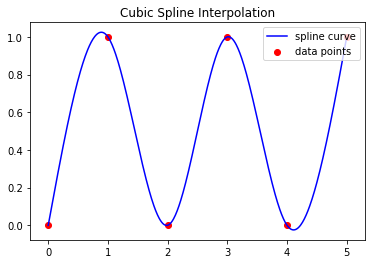

In [2]:
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])

x_val = np.arange(x[0], x[-1], 0.01)

A, B, C, D = setup_tridiagonal_matrix(x, y)
M_part = thomas_algorithm(A, B, C, D)
M = np.concatenate(([0], M_part, [0]))
spline = evaluate_spline(x, x_val, M)

plt.plot(x_val, spline, 'b', label='spline curve')
plt.scatter(x, y, color='r', label='data points')
plt.legend()
plt.title("Cubic Spline Interpolation")
plt.show()

citation: At first, for the j-value calculation for the evaluate_spline function, I was using too many for loops in attempts to continuously update j-values. However, the graph output was part of a cubic polynomial. So, I double-checked my code with Google Gemini to check for my error, and replaced my for loop with the while loop and updating the individual value of j instead of replacing the value of j for each loop.

I asked Gemini to check my code to "find the correct interval" of x_val in x.

My original code was:

        j = 0
        for a in range(0, m):
            for b in range(0, n):
                if x_val[a] > x[b]:
                    j = b-1